In [50]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
import os
sys.path.append('/content/drive/MyDrive/Shared Folder/Moon Mapping')


ModuleNotFoundError: No module named 'google.colab'

In [ ]:
print(os.listdir())


['.config', 'drive', 'sample_data']


In [7]:
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon
import cv2
import numpy as np
import pandas as pd
import os

In [8]:
import xml.etree.ElementTree as ET
import geopandas as gpd
from shapely.geometry import Polygon
import cv2
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from matplotlib.patches import Polygon as MatplotlibPolygon


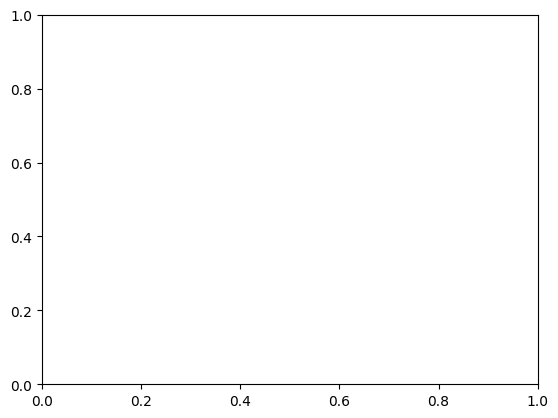

In [17]:

def file_coords(xml_file_path = r'E:\ISRO PS-Transformer\DataSet\OHRC\ch2_ohr_nrp_20200229T0938004033_d_img_d32\data\raw\20200229\ch2_ohr_nrp_20200229T0938004033_d_img_d32.xml'):
    tree = ET.parse(xml_file_path)
    root = tree.getroot()

    # Define the namespace dictionary
    namespace = {
        'isda': 'https://isda.issdc.gov.in/pds4/isda/v1',
    }

    # Function to extract latitude and longitude values
    def extract_coordinates(element):
        coordinates = element.find('.//isda:System_Level_Coordinates', namespace)
        upper_left_latitude = coordinates.find('./isda:upper_left_latitude', namespace).text
        upper_left_longitude = coordinates.find('./isda:upper_left_longitude', namespace).text

        upper_right_latitude = coordinates.find('./isda:upper_right_latitude', namespace).text
        upper_right_longitude = coordinates.find('./isda:upper_right_longitude', namespace).text

        lower_left_latitude = coordinates.find('./isda:lower_left_latitude', namespace).text
        lower_left_longitude = coordinates.find('./isda:lower_left_longitude', namespace).text

        lower_right_latitude = coordinates.find('./isda:lower_right_latitude', namespace).text
        lower_right_longitude = coordinates.find('./isda:lower_right_longitude', namespace).text

        return [(lower_left_longitude, lower_left_latitude), (lower_right_longitude, lower_right_latitude), (upper_right_longitude, upper_right_latitude), (upper_left_longitude, upper_left_latitude)]

    # Extract coordinates from the XML
    coordinates = extract_coordinates(root)
    # Print the results
    return coordinates

fig, ax = plt.subplots()


def common_intersec(fig1, fig2):
    # Create two polygons

    polygon1 = Polygon(fig1)
    polygon2 = Polygon(fig2)

    # print(fig1, fig2)
    if not polygon1.is_valid or not polygon2.is_valid:
        print("Buffering")
        polygon1 = polygon1.buffer(0)
        polygon2 = polygon2.buffer(0)

    x1, y1 = polygon1.exterior.xy
    x2, y2 = polygon2.exterior.xy
        # Create a Matplotlib Polygon and add it to the plot
    ax.add_patch(MatplotlibPolygon(xy=list(zip(x1, y1)), fill=True, edgecolor='black', facecolor='blue'))
    ax.add_patch(MatplotlibPolygon(xy=list(zip(x2, y2)), fill=True, edgecolor='black', facecolor='green'))
    # Find the intersection (common area) between the polygons
    intersection = polygon1.intersection(polygon2)
    # If the intersection is a Polygon (not empty), get its exterior (boundary) coordinates
    if intersection.is_empty:
        return None
    else:
        if intersection.geom_type == 'Polygon':
            common_area_coordinates = list(intersection.exterior.coords)
            return common_area_coordinates
        else:
            # If the intersection is a MultiPolygon, consider the first polygon's exterior
            first_polygon = list(intersection)[0]
            common_area_coordinates = list(first_polygon.exterior.coords)
            return common_area_coordinates


def cut_out_quadrilateral(image_path, output_path, src_coordinates, dst_coordinates):
    # Read the image
    image = cv2.imread(image_path)

    # Convert the coordinates to NumPy arrays
    src_pts = np.array(src_coordinates, dtype=np.float32)
    dst_pts = np.array(dst_coordinates, dtype=np.float32)

    # Calculate the perspective transformation matrix
    perspective_matrix = cv2.getPerspectiveTransform(src_pts, dst_pts)

    # Apply the perspective transformation to obtain the cut-out region
    warped_image = cv2.warpPerspective(image, perspective_matrix, (image.shape[1], image.shape[0]))

    # Save the cut-out region to a new image file
    cv2.imwrite(output_path, warped_image)

def find_common_area(poly1_coords, poly2_coords):
    # Create GeoDataFrame with the provided coordinates and custom CRS for the Moon
    moon_crs = "+proj=longlat +a=1737400 +b=1737400 +no_defs"  # Example CRS for the Moon
    poly1 = Polygon(poly1_coords)
    poly2 = Polygon(poly2_coords)

    if not poly1.is_valid or not poly2.is_valid:
        poly1 = poly1.buffer(0)
        poly2 = poly2.buffer(0)
        
    gdf = gpd.GeoDataFrame(geometry=[poly1, poly2], crs=moon_crs)

    # Find the intersection of the two polygons
    intersection = gdf.geometry.iloc[0].intersection(gdf.geometry.iloc[1])

    # Check if there is a common area
    if intersection.is_empty:
        return None

    # Extract the coordinates from the common area geometry
    common_area_coords = list(intersection.exterior.coords)

    return common_area_coords

files1={}
files2={}

def iterate_files(base_dir):
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.xml'):
                file_path = os.path.join(root, file)
                return file_path

def iterate_images(base_dir):
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.png'):
                file_path = os.path.join(root, file)
                return file_path

def browse_folders(base_dir, data):
    for entry in os.scandir(base_dir):
        if entry.is_dir():
            folder_name = entry.name
            data[folder_name] = file_coords(iterate_files(os.path.join(base_dir, folder_name, "data")))



# Function to find XML files and generate PNG file link
def parse_xml_and_get_png(xml_file_path, base_dir):
    # Extracting information from XML file path
    xml_filename = os.path.basename(xml_file_path)
    date_folder = os.path.basename(os.path.dirname(xml_file_path))
    channel = xml_filename.split('_')[0]

    # Creating corresponding PNG file path
    png_filename = xml_filename.replace('d_img', 'b_brw').replace('.xml', '.png')
    png_file_path = os.path.join(base_dir, 'browse', 'calibrated', date_folder, png_filename)

    return png_file_path

# Function to parse all XML files under the 'data\calibrated' directory and create a dictionary
def parse_all_xml_files(directory, base_dir):
    xml_files_dict = {}
    for root, dirs, files in os.walk(os.path.join(base_dir, 'data', 'calibrated')):
        for file in files:
            if file.endswith('.xml'):
                xml_file_path = os.path.join(root, file)
                png_file_path = parse_xml_and_get_png(xml_file_path, base_dir)
                xml_files_dict[file] = [file_coords(xml_file_path), png_file_path]

    return xml_files_dict

base_dir = r'G:\My Drive\Moon Mapping\DataSet\OHRC\files'
xml_files_dict_ohrc = parse_all_xml_files(os.path.join(base_dir, 'data', 'calibrated'), base_dir)


coor_csv = pd.read_csv(r"G:\My Drive\Moon Mapping\DataSet\TMC\coordinates.csv")
def iterate_tmc(base_dir, coor_csv):
    tmc_files = {}
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.png'):
                file_path = os.path.join(root, file)
                filename =file.split('_b')[0]
                row = coor_csv[coor_csv['Filename'].str.startswith(filename)]
                upper_left_latitude = row['upper_left_latitude'].iloc[0]
                upper_left_longitude = row['upper_left_longitude'].iloc[0]

                upper_right_latitude = row['upper_right_latitude'].iloc[0]
                upper_right_longitude = row['upper_right_longitude'].iloc[0]

                lower_left_latitude = row['lower_left_latitude'].iloc[0]
                lower_left_longitude = row['lower_left_longitude'].iloc[0]

                lower_right_latitude = row['lower_right_latitude'].iloc[0]
                lower_right_longitude = row['lower_right_longitude'].iloc[0]

                tmc_files[file] = [[(lower_left_longitude, lower_left_latitude), (lower_right_longitude, lower_right_latitude), (upper_right_longitude, upper_right_latitude), (upper_left_longitude, upper_left_latitude)], file_path]

    return tmc_files



In [18]:
xml_files_dict_tmc = iterate_tmc(r'G:\My Drive\Moon Mapping\DataSet\TMC', coor_csv)

output_path1 = r'G:\My Drive\Moon Mapping\DataSet\Test'
output_path2 = r'G:\My Drive\Moon Mapping\DataSet\GT'

In [19]:


iterator = 0
it = 0
for image_tmc in xml_files_dict_tmc:
    for image_ohrc in xml_files_dict_ohrc:
        if(not (np.isnan(xml_files_dict_tmc[image_tmc][0])).any()):
            intersect = find_common_area(xml_files_dict_tmc[image_tmc][0], xml_files_dict_ohrc[image_ohrc][0])
            it += 1
            if(intersect is not None and len(intersect)==5):
                intersect.pop()
                # cut_out_quadrilateral(xml_files_dict_tmc[image_tmc][1], output_path1 + rf'\{iterator}_{image_tmc[:-4]}.png', xml_files_dict_tmc[image_tmc][0], intersect)
                # cut_out_quadrilateral(xml_files_dict_ohrc[image_ohrc][1], output_path2 + rf'\{iterator}_{image_ohrc[:-4]}.png', xml_files_dict_ohrc[image_ohrc][0], intersect)
                iterator += 1
        else:
            continue

print(iterator)

334


In [20]:
plt.show()

In [21]:
print(image_tmc, image_ohrc)

ch2_tmc_nca_20220120T1525473341_b_brw_d18.png ch2_ohr_ncp_20210331T2033243734_d_img_d18.xml


In [22]:
print(xml_files_dict_ohrc[image_ohrc])
img = cv2.imread('G:\\My Drive\\Moon Mapping\\DataSet\\OHRC\\files\\browse\\calibrated\\20230823\\ch2_ohr_ncp_20230823T1450475804_b_brw_n18_n18.png')
print(img)

[[('41.414143', '-20.524168'), ('41.531490', '-20.525091'), ('41.523235', '-19.695877'), ('41.406534', '-19.694932')], 'G:\\My Drive\\Moon Mapping\\DataSet\\OHRC\\files\\browse\\calibrated\\20210331\\ch2_ohr_ncp_20210331T2033243734_b_brw_d18.png']
None


In [23]:
def cut_out_quadrilateral(image_path, output_path, src_coordinates, dst_coordinates):
    # Read the image
    image = cv2.imread(image_path)
    # Convert the coordinates to NumPy arrays
    src_pts = np.array(src_coordinates, dtype=np.float32)
    dst_pts = np.array(dst_coordinates, dtype=np.float32)

    print("Source Points:", src_pts)
    print("Destination Points:", dst_pts)

    # Convert BGR image to RGB (matplotlib uses RGB)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image using matplotlib
    plt.imshow(image_rgb)
    plt.axis('off')  # Turn off axis labels
    plt.show()
    # Calculate the perspective transformation matrix
    perspective_matrix = cv2.getPerspectiveTransform(src_pts, dst_pts)

    # Apply the perspective transformation to obtain the cut-out region
    warped_image = cv2.warpPerspective(image, perspective_matrix, (image.shape[1], image.shape[0]))
    # Convert BGR image to RGB (matplotlib uses RGB)
    image_rgb = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB)

    # Display the image using matplotlib
    plt.imshow(image_rgb)
    plt.axis('off')  # Turn off axis labels
    plt.show()
    # Save the cut-out region to a new image file
    cv2.imwrite(output_path, warped_image)

In [24]:
cut_out_quadrilateral(xml_files_dict_tmc[image_tmc][1], output_path1 + rf'\{iterator}_{image_tmc[:-4]}.png', xml_files_dict_tmc[image_tmc][0], intersect)

Source Points: [[-66.210396 -63.073578]
 [-67.816    -63.05522 ]
 [118.000755 -72.83739 ]
 [115.34928  -72.870186]]
Destination Points: nan


error: OpenCV(4.9.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\imgwarp.cpp:3547: error: (-215:Assertion failed) src.checkVector(2, CV_32F) == 4 && dst.checkVector(2, CV_32F) == 4 in function 'cv::getPerspectiveTransform'


[(100.0, 50.0), (50.0, 50.0), (50.0, 100.0), (100.0, 100.0), (100.0, 50.0)]
Source Points: [[  0.   0.]
 [100.   0.]
 [100. 100.]
 [  0. 100.]]
Destination Points: [[ 50.  50.]
 [100.  50.]
 [100. 100.]
 [ 50. 100.]]


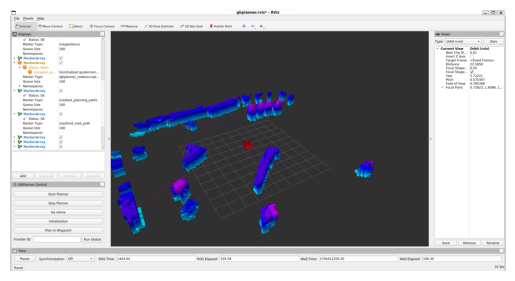

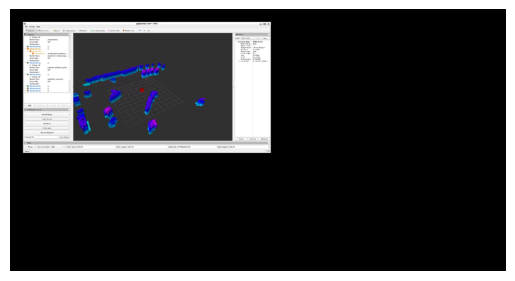

In [ ]:
src_coordinates = [
    [0, 0],
    [100, 0],
    [100, 100],
    [0, 100]
]

# Example destination coordinates
dst_coordinates = [
    [50, 50],
    [100, 50],
    [100, 100],
    [50, 100]
]
print(common_intersec(src_coordinates, dst_coordinates))
cut_out_quadrilateral(r"C:\users\Sukhvansh Jain\OneDrive\Pictures\Screenshots\Screenshot 2024-01-05 141807.png", output_path1 + rf'\{iterator}_{image_tmc[:-4]}.png', src_coordinates, dst_coordinates)

In [ ]:

import cv2
import numpy as np

def crop_image_with_perspective_transformation(image_path, src_coords, dst_coords, output_path='output_cropped_image.jpg'):
    # Read the input image
    image = cv2.imread(image_path)

    # Convert source and destination coordinates to NumPy arrays
    src_points = np.array(src_coords, dtype=np.float32)
    dst_points = np.array(dst_coords, dtype=np.float32)

    # Compute the homography matrix
    homography_matrix, _ = cv2.findHomography(src_points, dst_points)

    # Warp the image using the homography matrix
    warped_image = cv2.warpPerspective(image, homography_matrix, (image.shape[1], image.shape[0]))

    # Find the bounding box of the destination region
    bounding_box = cv2.boundingRect(dst_points)

    # Crop the warped image to the bounding box
    cropped_image = warped_image[bounding_box[1]:bounding_box[1]+bounding_box[3], bounding_box[0]:bounding_box[0]+bounding_box[2]]

    # Save or display the resulting cropped image
    cv2.imwrite(output_path, cropped_image)


# Example coordinates for cutting out a quadrilateral region
src_coordinates = [
    [0, 0],
    [100, 0],
    [100, 100],
    [0, 100]
]

# Example destination coordinates
dst_coordinates = [
    [0, 0],
    [50, 0],
    [50, 50],
    [0, 50]
]

# Call the cut_out_quadrilateral function with these coordinates
crop_image_with_perspective_transformation(r"C:\users\Sukhvansh Jain\OneDrive\Pictures\Screenshots\Screenshot 2024-01-05 141807.png", src_coordinates, dst_coordinates, 'result.png')


In [ ]:
from PIL import Image

def cut_and_save_image(image_path, src_coordinates, dest_coordinates, output_path):
    # Open the image
    img = Image.open(image_path)

    # Extract individual coordinates
    src = tuple(map(int, src_coordinates[0])), tuple(map(int, src_coordinates[1])), tuple(map(int, src_coordinates[2])), tuple(map(int, src_coordinates[3]))
    dest = tuple(map(int, dest_coordinates[0])), tuple(map(int, dest_coordinates[1])), tuple(map(int, dest_coordinates[2])), tuple(map(int, dest_coordinates[3]))

    # Crop the image using the provided coordinates
    cropped_img = img.crop(src)

    # Create a new image with the destination coordinates
    new_img = Image.new('RGB', (dest[2][0] - dest[0][0], dest[2][1] - dest[0][1]))
    new_img.paste(cropped_img, (0, 0))

    # Save the new image
    new_img.save(output_path)

# Example usage
image_path = r"C:\users\Sukhvansh Jain\OneDrive\Pictures\Screenshots\Screenshot 2024-01-05 141807.png"
src_coordinates = ((107, 23), (7, 23), (107, 123), (107, 123))
dest_coordinates = ((57, 23), (7, 23), (7, 73), (57, 73))
output_path = "test.png"

cut_and_save_image(image_path, src_coordinates, dest_coordinates, output_path)

TypeError: type tuple doesn't define __round__ method

In [ ]:
from PIL import Image
import numpy as np

def map_and_crop_image(src_coords, dest_coords, image_path):
    """Maps an image to specified coordinates and crops a portion of it.

    Args:
        src_coords: A list of 4 tuples representing the source coordinates in the format (x1, y1), (x2, y2), ...
        dest_coords: A list of 4 tuples representing the destination coordinates in the same format.
        image_path: The path to the image file.

    Returns:
        The cropped image as a PIL Image object.
    """

    # Load the image
    image = Image.open(image_path)
    width, height = image.size

    # Get source and destination points as NumPy arrays
    src_pts = np.array(src_coords)
    dest_pts = np.array(dest_coords)

    # Calculate perspective transform matrix
    transform_matrix = cv2.getPerspectiveTransform(src_pts, dest_pts)

    # Apply perspective transform to the image
    warped_image = cv2.warpPerspective(image, transform_matrix, (width, height))

    # Extract the bounding box of the destination coordinates
    min_x, min_y = np.min(dest_pts, axis=0)
    max_x, max_y = np.max(dest_pts, axis=0)

    # Crop the warped image using the bounding box
    cropped_image = warped_image.crop((min_x, min_y, max_x, max_y))

    return cropped_image

# Example usage:
src_coordinates = [
    [0, 0],
    [100, 0],
    [100, 100],
    [0, 100]
]

# Example destination coordinates
dst_coordinates = [
    [0, 0],
    [50, 0],
    [50, 50],
    [0, 50]
]
image_path = r"C:\users\Sukhvansh Jain\OneDrive\Pictures\Screenshots\Screenshot 2024-01-05 141807.png"

cropped_image = map_and_crop_image(src_coordinates, dst_coordinates, image_path)
cropped_image.save("cropped_image.png")

error: OpenCV(4.9.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\imgwarp.cpp:3547: error: (-215:Assertion failed) src.checkVector(2, CV_32F) == 4 && dst.checkVector(2, CV_32F) == 4 in function 'cv::getPerspectiveTransform'


In [ ]:
import geopandas as gpd
from shapely.geometry import Polygon

def find_common_area(poly1_coords, poly2_coords):
    # Create GeoDataFrame with the provided coordinates
    poly1 = Polygon(poly1_coords)
    poly2 = Polygon(poly2_coords)

    gdf = gpd.GeoDataFrame(geometry=[poly1, poly2], crs='EPSG:4326')
    print(gdf)
    # Find the intersection of the two polygons
    intersection = gdf.unary_union

    # Check if there is a common area
    if intersection.is_empty:
        print("There is no common area between the two polygons.")
        return None

    # Retrieve the coordinates of the common area
    common_area_coords = list(intersection.exterior.coords)

    return common_area_coords

# Example coordinates for two polygons
polygon1_coordinates = [(0, 0), (0, 1), (1, 1), (1, 0), (0, 0)]
polygon2_coordinates = [(0.5, 0.5), (0.5, 1.5), (1.5, 1.5), (1.5, 0.5), (0.5, 0.5)]

# Find the common area coordinates
common_area_coordinates = find_common_area(polygon1_coordinates, polygon2_coordinates)

# Print the result
if common_area_coordinates:
    print("Coordinates of the common area:")
    for lon, lat in common_area_coordinates:
        print(f"Latitude: {lat}, Longitude: {lon}")


                                            geometry
0  POLYGON ((0.00000 0.00000, 0.00000 1.00000, 1....
1  POLYGON ((0.50000 0.50000, 0.50000 1.50000, 1....
Coordinates of the common area:
Latitude: 1.0, Longitude: 0.0
Latitude: 1.0, Longitude: 0.5
Latitude: 1.5, Longitude: 0.5
Latitude: 1.5, Longitude: 1.5
Latitude: 0.5, Longitude: 1.5
Latitude: 0.5, Longitude: 1.0
Latitude: 0.0, Longitude: 1.0
Latitude: 0.0, Longitude: 0.0
Latitude: 1.0, Longitude: 0.0


In [ ]:
import geopandas as gpd
from shapely.geometry import Polygon

def find_common_area(poly1_coords, poly2_coords):
    # Create GeoDataFrame with the provided coordinates and custom CRS for the Moon
    moon_crs = "+proj=longlat +a=1737400 +b=1737400 +no_defs"  # Example CRS for the Moon
    poly1 = Polygon(poly1_coords)
    poly2 = Polygon(poly2_coords)

    gdf = gpd.GeoDataFrame(geometry=[poly1, poly2], crs=moon_crs)

    # Find the intersection of the two polygons
    intersection = gdf.geometry.iloc[0].intersection(gdf.geometry.iloc[1])

    # Check if there is a common area
    if intersection.geom_type == 'MultiPolygon':
        common_area_coords = []
        for polygon in intersection:
            common_area_coords.extend(list(polygon.exterior.coords))
    else:
        common_area_coords = list(intersection.exterior.coords)

    # Extract the coordinates from the common area geometry
    common_area_coords = list(intersection.exterior.coords)

    return common_area_coords

# Example coordinates for two Moon polygons
# Note: Adjust the coordinates based on your specific use case
polygon1_coordinates = [(-50, 0), (-50, 10), (-40, 10), (-40, 0), (-50, 0)]
polygon2_coordinates = [(-45, 5), (-45, 15), (-35, 15), (-35, 5), (-45, 5)]

# Find the common area coordinates
common_area_coordinates = find_common_area(polygon1_coordinates, polygon2_coordinates)

# Print the result
if common_area_coordinates:
    print("Coordinates of the common area:")
    for lon, lat in common_area_coordinates:
        print(f"Latitude: {lat}, Longitude: {lon}")


Coordinates of the common area:
Latitude: 10.0, Longitude: -40.0
Latitude: 5.0, Longitude: -40.0
Latitude: 5.0, Longitude: -45.0
Latitude: 10.0, Longitude: -45.0
Latitude: 10.0, Longitude: -40.0


In [ ]:
spherical_polygon1 = [(0, 89), (45, 89), (45, 80), (0, 80), (0, 89)]
spherical_polygon2 = [(0, -89), (45, -89), (45, -80), (0, -80), (0, -89)]

# Find the common area coordinates
common_area_coordinates = find_common_area(spherical_polygon1, spherical_polygon2)
print(common_area_coordinates)
# Print the result
if common_area_coordinates:
    print("Coordinates of the common area:")
    for lon, lat in common_area_coordinates:
        print(f"Latitude: {lat}, Longitude: {lon}")

There is no common area between the two polygons.
None


In [ ]:
spherical_polygon1 = [(0, 89), (45, 89), (45, 80), (0, 80), (0, 89)]
spherical_polygon2 = [(0, -89), (45, -89), (45, -80), (0, -80), (0, -89)]

# Find the common area coordinates
common_area_coordinates = common_intersec(spherical_polygon1, spherical_polygon2)

# Print the result
if common_area_coordinates:
    print("Coordinates of the common area:")
    for lon, lat in common_area_coordinates:
        print(f"Latitude: {lat}, Longitude: {lon}")

NameError: name 'common_intersec' is not defined

In [ ]:
import xml.etree.ElementTree as ET

def extract_time_coordinates(xml_file_path):
    try:
        # Parse the XML
        tree = ET.parse(xml_file_path)
        root = tree.getroot()

        # Find the start_date_time and stop_date_time elements
        start_date_time_element = root.find(".//{http://pds.nasa.gov/pds4/pds/v1}start_date_time")
        stop_date_time_element = root.find(".//{http://pds.nasa.gov/pds4/pds/v1}stop_date_time")

        # Extract the values
        start_date_time = start_date_time_element.text if start_date_time_element is not None else None
        stop_date_time = stop_date_time_element.text if stop_date_time_element is not None else None

        return start_date_time, stop_date_time
    except Exception as e:
        print(f"Error: {e}")
        return None, None

# Example usage:
xml_file_path = r"G:\My Drive\Moon Mapping\DataSet\OHRC\files\browse\calibrated\20190906\ch2_ohr_ncp_20190906T1246532096_b_brw_d18.xml"
start_time, stop_time = extract_time_coordinates(xml_file_path)

if start_time and stop_time:
    print("Start Date-Time:", start_time)
    print("Stop Date-Time:", stop_time)
else:
    print("Failed to extract time coordinates.")


Start Date-Time: 2019-09-06T12:46:53.2096Z
Stop Date-Time: 2019-09-06T12:47:04.4732Z
